
---

# 🚀 ***`Outliers in Machine Learning for Data Science`*** 📊  

**Outliers** are **data points that deviate significantly** from the majority of observations in a dataset. They can **distort model predictions, reduce accuracy, and create biased results** in Machine Learning (ML).  

---

## 🎯 **1. What are Outliers?**  

📌 **Outliers are extreme values that differ significantly from the rest of the data.** They may occur due to:  
- **Measurement errors** (e.g., incorrect sensor readings)  
- **Data entry mistakes** (e.g., extra zeros in salary data)  
- **Natural variations** (e.g., unusually high stock prices)  
- **Rare but important events** (e.g., fraudulent transactions)  

### **Types of Outliers:**  
1. **Global Outliers (Point Anomalies)** → Extreme values compared to the entire dataset.  
   - Example: A house priced at **$10 million** in a dataset where most houses cost **$100,000 - $500,000**.  

2. **Contextual Outliers (Conditional Anomalies)** → Values that are only unusual in a specific context.  
   - Example: **High electricity usage at midnight** is unusual, but normal during the day.  

3. **Collective Outliers** → A group of data points behaving differently from the rest.  
   - Example: **Sudden drop in website traffic** could indicate a system failure.  

---

## ⚠️ **2. When Are Outliers Dangerous?**  

Outliers are **dangerous** when they:  
❌ **Skew results** → Affect mean, standard deviation, and correlation.  
❌ **Reduce model accuracy** → Influence parameter estimation (e.g., in regression).  
❌ **Cause overfitting** → Some models may learn noise instead of patterns.  
❌ **Affect decision-making** → False conclusions in data analysis.  

🔹 **When Outliers Are Useful:**  
✅ In **fraud detection** (e.g., unusual financial transactions).  
✅ In **anomaly detection** (e.g., identifying system failures).  
✅ In **medical diagnosis** (e.g., detecting rare diseases).  

---

## 🎯 **3. Effect of Outliers on ML Algorithms**  

### **📉 Algorithms Affected by Outliers:**
| **Algorithm**                | **Impact of Outliers** |
|------------------------------|----------------------|
| **Linear Regression**        | 📉 Skews predictions, affects coefficients. |
| **Logistic Regression**      | 📉 Reduces decision boundary accuracy. |
| **K-Means Clustering**       | 📉 Can distort centroids & affect clusters. |
| **K-Nearest Neighbors (KNN)** | 📉 Outliers affect distance calculations. |
| **Principal Component Analysis (PCA)** | 📉 Can distort principal components. |

---

## 🔍 **4. How to Detect Outliers?**  

There are **two main approaches**:  
1️⃣ **Statistical Methods** → Based on numerical thresholds.  
2️⃣ **Machine Learning Methods** → Using clustering & anomaly detection models.  

---

## 🛠 **5. Techniques for Outlier Detection**  

### 📊 **1. Visualization Techniques**  
**✅ Best for small datasets.**  
📌 Helps visually identify extreme values.  

#### **🔹 Box Plot (Using IQR Method)**  

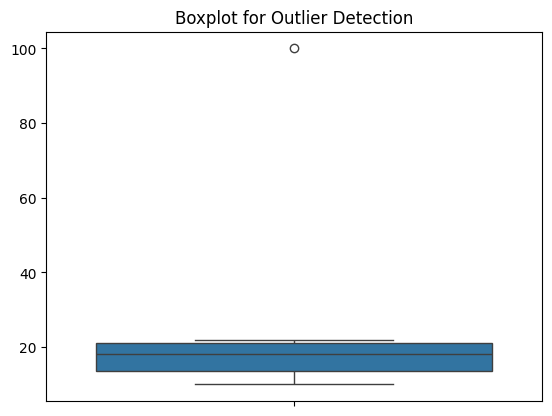

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sample Data
data = [10, 12, 15, 18, 20, 22, 100]  # 100 is an outlier

# Plot
sns.boxplot(data=data)
plt.title("Boxplot for Outlier Detection")
plt.show()


📌 **Points outside the whiskers** (1.5×IQR) are **outliers**.

---

#### **🔹 Scatter Plot**

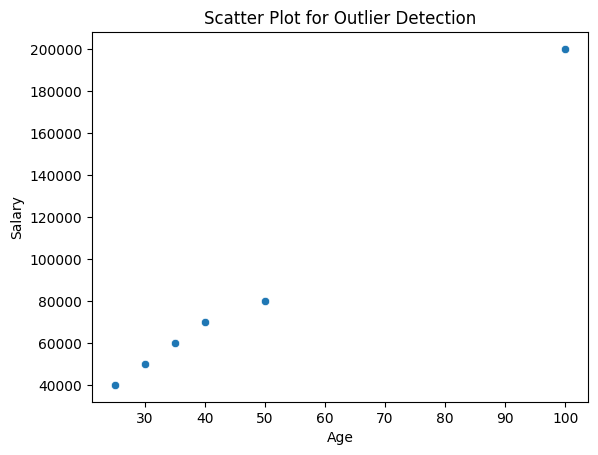

In [2]:
import numpy as np
import pandas as pd

# Sample Data
df = pd.DataFrame({'Age': [25, 30, 35, 40, 50, 100], 'Salary': [40000, 50000, 60000, 70000, 80000, 200000]})

# Scatter Plot
sns.scatterplot(x=df['Age'], y=df['Salary'])
plt.title("Scatter Plot for Outlier Detection")
plt.show()


📌 **Unusual points far from the cluster** indicate outliers.

---

### 📏 **2. Statistical Methods**  

#### **🔹 Z-Score Method**  
**✅ Best for Normally Distributed Data**  
📌 Outliers have a **Z-score > 3 or < -3**.  

In [3]:
from scipy import stats
import numpy as np

# Sample Data
data = np.array([10, 12, 15, 18, 20, 22, 100])

# Compute Z-Scores
z_scores = stats.zscore(data)

# Identify Outliers
outliers = data[np.abs(z_scores) > 3]
print("Outliers:", outliers)

Outliers: []



📌 **Values with Z-scores above 3 are outliers.**

---

#### **🔹 Interquartile Range (IQR) Method**  
**✅ Best for Skewed Data**  
📌 Outliers are **outside 1.5×IQR** range.  

In [4]:
# Compute IQR
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)
IQR = Q3 - Q1

# Define Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify Outliers
outliers = data[(data < lower_bound) | (data > upper_bound)]
print("Outliers:", outliers)

Outliers: [100]



📌 **Values outside 1.5×IQR range are outliers.**

---

### 🤖 **3. Machine Learning-Based Methods**  

#### **🔹 Isolation Forest (Unsupervised Anomaly Detection)**
📌 **Assigns anomaly scores** to identify outliers.

In [5]:
from sklearn.ensemble import IsolationForest

# Sample Data
df = pd.DataFrame({'Age': [25, 30, 35, 40, 50, 100], 'Salary': [40000, 50000, 60000, 70000, 80000, 200000]})

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
df['Anomaly'] = iso_forest.fit_predict(df[['Age', 'Salary']])

# Identify Outliers
outliers = df[df['Anomaly'] == -1]
print("Outliers:\n", outliers)

Outliers:
    Age  Salary  Anomaly
5  100  200000       -1



📌 **-1 indicates an anomaly (outlier).**

---

#### **🔹 DBSCAN (Density-Based Clustering)**
📌 **Finds outliers by detecting low-density points.**

In [6]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=10, min_samples=2)
df['Cluster'] = dbscan.fit_predict(df[['Age', 'Salary']])

# Identify Outliers
outliers = df[df['Cluster'] == -1]
print("Outliers:\n", outliers)

Outliers:
    Age  Salary  Anomaly  Cluster
0   25   40000        1       -1
1   30   50000        1       -1
2   35   60000        1       -1
3   40   70000        1       -1
4   50   80000        1       -1
5  100  200000       -1       -1


📌 **-1 indicates noise (outliers).**

---

## 🛠 **6. How to Treat Outliers?**  

| **Method**             | **When to Use?** |
|-----------------------|------------------|
| **Remove Outliers**   | If they are due to errors |
| **Cap/Floor Outliers** | When outliers are valid but extreme |
| **Transform Data (Log, Box-Cox)** | If distribution is skewed |
| **Use Robust Models (Tree-based)** | Models like Random Forest handle outliers well |

---

## 🎯 **7. Choosing the Right Outlier Detection Method**  

| **Scenario**             | **Recommended Method** |
|-------------------------|------------------|
| **Small dataset** | **Box Plot, Scatter Plot** |
| **Normally distributed data** | **Z-score Method** |
| **Skewed data** | **IQR Method** |
| **Unsupervised Anomaly Detection** | **Isolation Forest** |
| **Clustering anomalies** | **DBSCAN** |

---

## 🏆 **8. Final Thoughts**  

✔ **Outliers can distort ML models, but they also provide valuable insights.**  
✔ **Use visualization (Boxplot, Scatterplot) before applying statistical methods.**  
✔ **Choose detection techniques based on data distribution.**  
✔ **Use machine learning (Isolation Forest, DBSCAN) for complex data.**  
✔ **Always validate whether outliers should be removed or kept.**  

💡 **Pro Tip:** Always **test model performance with & without outliers** before making final decisions!

---